In [1]:
print("hello world")

hello world


In [2]:
a = 2
b = 3
print(a + b)

5


In [3]:
import numpy as np
import pandas as pd

In [6]:
print(a*b)

6


In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train a simple ML model (logistic regression) on synthetic data

X, y = make_classification(n_samples=300, n_features=5, n_informative=3, n_redundant=0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8666666666666667
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        42
           1       0.83      0.94      0.88        48

    accuracy                           0.87        90
   macro avg       0.88      0.86      0.86        90
weighted avg       0.87      0.87      0.87        90



ModuleNotFoundError: No module named 'yfinance'

ModuleNotFoundError: No module named 'yfinance'

In [5]:
import sys
print(sys.executable)


c:\Users\user\anaconda3\python.exe


In [6]:
import yfinance as yf
import pandas as pd
import numpy as np

ModuleNotFoundError: No module named 'yfinance'

In [7]:
import sys
!{sys.executable} -m pip install yfinance


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 12.3 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15617 sha256=7c5625b2c3422613d4a673bccda292d1fe9890194d88787915a75c923763863e
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\cc\bd\6f\664d62c99327abeef7d86489e6631cbf45b56fbf7ef1d6ef00
Successfully built multitasking


In [16]:
import yfinance as yf
import pandas as pd
import numpy as np


In [17]:
# Download historical stock data
data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

data = data[['Close']]


[*********************100%***********************]  1 of 1 completed


In [18]:
# Moving averages
data['SMA_20'] = data['Close'].rolling(window=20).mean()
data['SMA_50'] = data['Close'].rolling(window=50).mean()

data['Signal'] = 0
data.loc[data['SMA_20'] > data['SMA_50'], 'Signal'] = 1



In [19]:
# Daily returns
data['Market_Return'] = data['Close'].pct_change()

# Strategy returns (shift to avoid lookahead bias)
data['Strategy_Return'] = data['Signal'].shift(1) * data['Market_Return']

# Cumulative performance
data['Market_Cumulative'] = (1 + data['Market_Return']).cumprod()
data['Strategy_Cumulative'] = (1 + data['Strategy_Return']).cumprod()


In [20]:
final_market = data['Market_Cumulative'].iloc[-1]
final_strategy = data['Strategy_Cumulative'].iloc[-1]

print("Market Return:", round((final_market - 1) * 100, 2), "%")
print("Strategy Return:", round((final_strategy - 1) * 100, 2), "%")


Market Return: 163.19 %
Strategy Return: 69.08 %


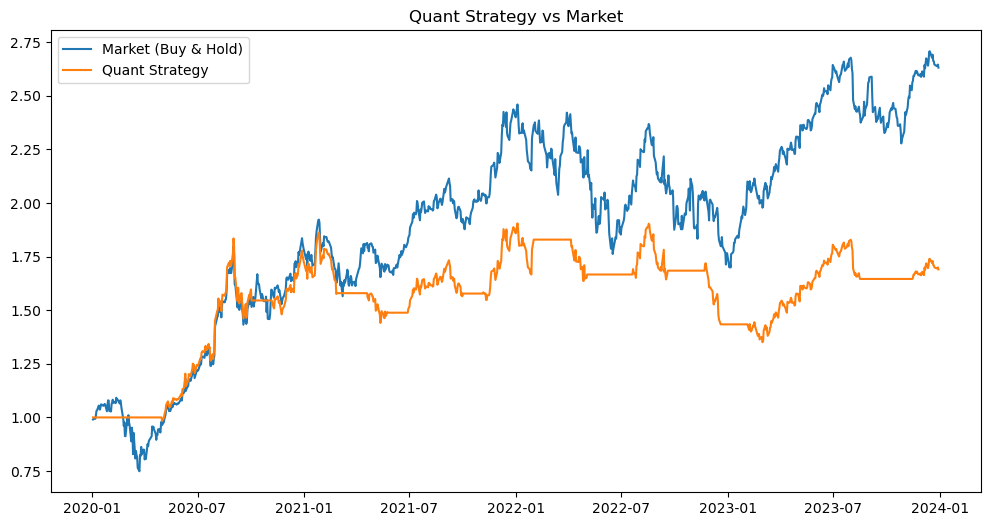

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data.index, data['Market_Cumulative'], label="Market (Buy & Hold)")
plt.plot(data.index, data['Strategy_Cumulative'], label="Quant Strategy")
plt.legend()
plt.title("Quant Strategy vs Market")
plt.show()


In [22]:
sharpe = (
    data['Strategy_Return'].mean() /
    data['Strategy_Return'].std()
) * np.sqrt(252)

print("Sharpe Ratio:", round(sharpe, 2))


Sharpe Ratio: 0.73


In [23]:
sharpe = (
    data['Strategy_Return'].mean() /
    data['Strategy_Return'].std()
) * np.sqrt(252)

print("Sharpe Ratio:", round(sharpe, 2))


Sharpe Ratio: 0.73
